# EDA for Shooting Analysis

### Torso Velocity & Body Motion + Torso Flexion & Extension


We conducted general EDA on all torso related variables, including: TorsoVeloPreHitch, TorsoVeloRelease, TorsoFlexionAtT0, etc. We dropped all players with less than 20 shots, and found that an average made rate of around 65%. Using this as a baseline, we conducted some EDA to get an idea of what torso variables are associated with makes. 

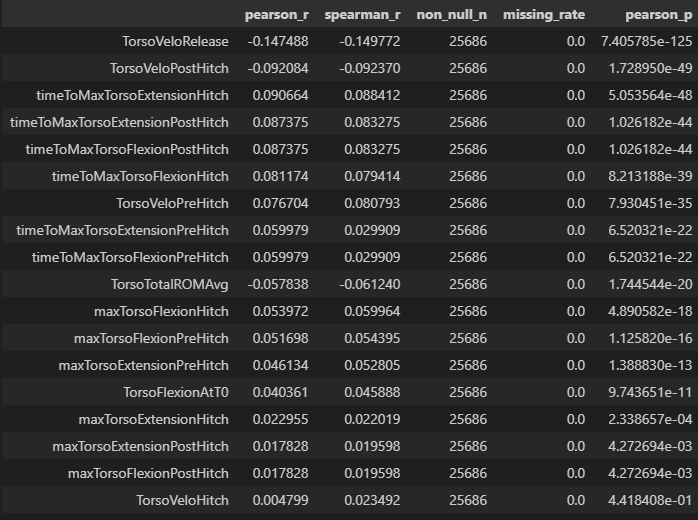

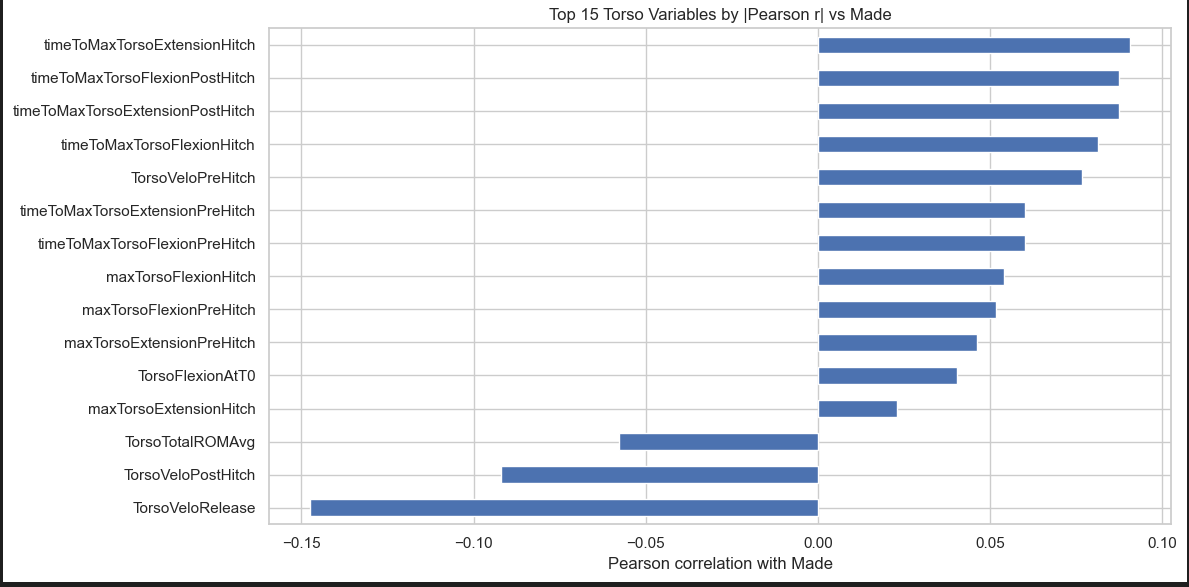

We can see that across all shots, a few torso timing and torso velocity measures show statistically detectable weak association with makes. This may be because we did not stratify for shot location or shot type, however if we stratify with those factors, then the number for shots (sample size) will dramatically decrease. Despite this, we can see that TorsoVeloRelease, timeToMaxTorsoExtentionHitch, and timeToMaxTorsoFlexionPostHitch has a tiny correlation with makes.

We also trained a Random Forest classifier on a free throw subset and examined feature imporatnce for the Torso variables and found that variables like TorsoveloRelease, TorsoVeloPostHitch, and TorsoVeloPreHitch were the top features. This aligns with the correlation based EDA conducted suggesting torso velocity and timing may potentially contain signal. However, given that the Random Forest model's predictive performance was weak with a ROC AUC of 0.619 (slightly better than chance), these variable importances should be interpereted cautiously.  

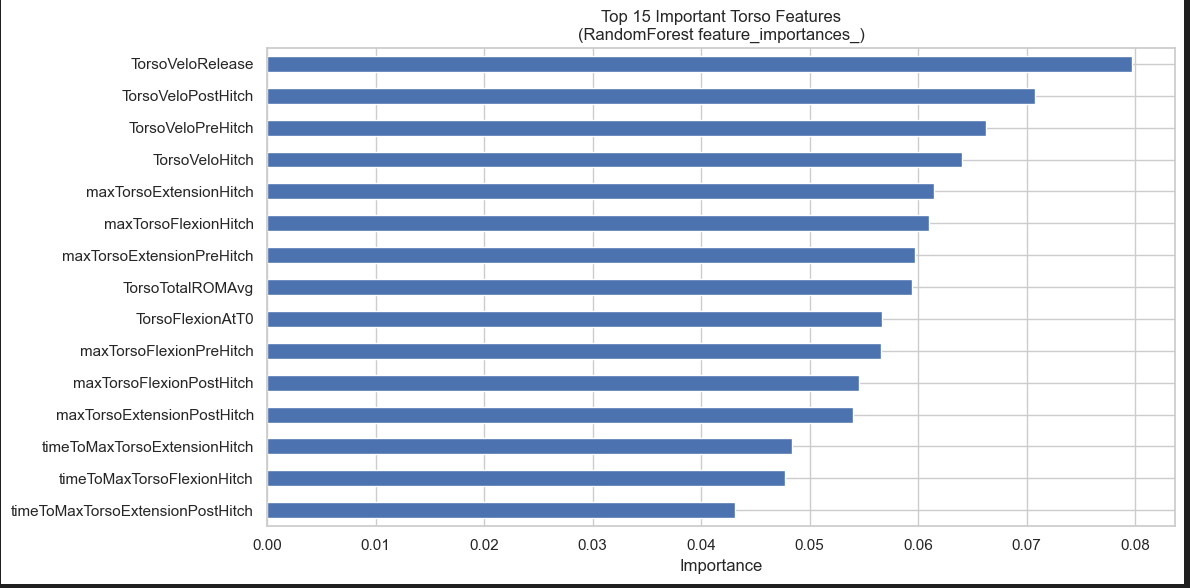

### Lower Body Mechanics 

We conducted EDA on all lower body mechanics including ankle, knee, and hip movement variables. We started our analysis by narrowing shot type to free throws. We conducted univariate analysis for all variables at the ankle, knee, and hip, identifying the most significant variables and plotting the model in order to identify trends and affects of these variables on shooting percentage. The goal of this analysis is to find which lower body mechanics are most significant, and which portion of the shot (pre-hitch, hitch, post-hitch) do these variables have the most impact.


##### Ankle Analysis

![Ankle Variables](LowerBodyImages/AnkleVariables.png)

The ankle analysis examined how variations in ankle mechanics relate to free throw success using logistic regression models for each variable. Results suggest that greater post-hitch plantarflexion is associated with an increased probability of making the shot, indicating that stronger ankle extension during the release phase may contribute to more effective shot mechanics.

![Ankle Variable Visual](LowerBodyImages/AnkleVariableVisual.png)

This graph plots the predicted probability of making a free throw against average maximum ankle plantarflexion post-hitch, based on a logistic regression model with maxAnklePlantarflexionAvgPostHitch as the sole predictor. Each point represents an observation’s predicted make probability, and the LOESS curve visualizes the overall trend in the relationship.

The plot shows a clear, approximately linear increasing relationship, where plantarflexion values from about -30 to 20 degrees correspond to an increase in predicted free throw probability from roughly 0.78 to 0.86. This suggests that greater ankle plantarflexion post-hitch is positively associated with higher free throw success probability in this model.


##### Knee Analysis

![Knee Variables](LowerBodyImages/KneeVariables.png)

The knee analysis evaluated the relationship between knee joint mechanics and free throw outcomes. The results indicate that increased post-hitch knee extension is positively associated with the likelihood of making a free throw, suggesting that greater leg drive and extension during the shooting motion may help generate a more consistent and controlled shot.

![Knee Variable Visual](LowerBodyImages/KneeVariableVisual.png)

This graph displays the predicted probability of making a free throw as a function of average maximum knee extension post-hitch, based on a logistic regression model with knee extension as the sole predictor. The points represent predicted probabilities for each observation, and the LOESS curve highlights the overall trend in the relationship.

The completed graph shows a strong negative, nearly linear relationship: as maxKneeExtensionAvgPostHitch increases (moves from about -65 toward 0), predicted free throw probability decreases from roughly 0.92 to about 0.76. This suggests that less negative (or smaller magnitude) knee extension post-hitch is associated with lower free throw success probability, while greater knee extension (more negative values in this dataset) corresponds to higher predicted make probability.


##### Hip Analysis

![Hip Variables](LowerBodyImages/HipVariables.png)

The hip analysis investigated how hip range of motion and flexion/extension patterns influence shot success. The findings show that total hip range of motion is significantly related to free throw probability, implying that greater lower-body mobility and fluidity through the hips may support a more coordinated shooting motion.

![Hip Variable Visual](LowerBodyImages/HipVariableVisual.png)

This graph shows the predicted probability of making a free throw as a function of average total hip range of motion, based on a logistic regression model using hipTotalROMAvg as the predictor. Each point represents an observation’s predicted make probability, and the smoothed curve highlights the overall trend between hip ROM and shot success.

The graph shows a strong positive relationship, where hipTotalROMAvg values closer to 0 correspond to higher predicted free throw probabilities. Because total ROM Avg is calculated by summing hip flexion (negative values) and hip extension (positive values), values closer to 0 indicate greater overall extension relative to flexion—suggesting that more complete hip extension during the shooting motion is associated with improved free throw success.

##### Overall Model (Most Significant Lower Body Variables)

![Logistic Regression Model](LowerBodyImages/LogisticRegressionModel.png)

A multivariate logistic regression model was built using the most significant ankle, knee, and hip variables.

This model evaluates which lower-body mechanics independently predict free throw success when accounting for all joints simultaneously. All biomechanical predictors were standardized to allow direct comparison of effect sizes across joints.

In this model, hipTotalROMAvg is the only variable that stays significant when accounting for ankle, knee, and hip movements together. This suggests that hipTotalROMAvg may be the primary driver of force generation in the kinetic chain, with ankle and knee effects largely explained by their coordination with overall hip extension during the shooting motion.

##### Clustering Analyis & PCA

![PCA Visual](LowerBodyImages/PCAVisual.png)

K-means clustering was applied to the most significant ankle, knee, and hip variables to identify groups of players with similar lower-body shooting mechanics. This approach helps reveal whether different mechanical patterns exist among shooters and whether certain movement profiles are associated with higher free throw success rates.

Principal Component Analysis (PCA) was used to visualize the mechanical differences between clusters. The PCA plot highlights how variations in ankle plantarflexion, knee extension, and hip range of motion contribute to distinct shooting movement patterns.

![PCA](LowerBodyImages/PCA.png)

The PCA plot shows three distinct clusters of lower-body shooting mechanics based on ankle plantarflexion, knee extension, and hip range of motion. The loadings indicate that PC1 is primarily driven by ankle plantarflexion (0.65) and knee extension (-0.66), while PC2 is strongly influenced by hip range of motion (0.93), suggesting that hip mobility explains much of the vertical separation between clusters in the plot. Cluster performance is relatively similar across groups, though Cluster 3 has the highest make rate (0.834) compared to Cluster 2 (0.822) and Cluster 1 (0.805), indicating slightly better free throw success for players with that mechanical profile.